In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
#load the dataset
df=pd.read_csv('Cleaned_datasets/Health_Coverage_Financial_Hardship.csv')

## Basic overview of the datasets

In [3]:
df.shape

(58848, 7)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58848 entries, 0 to 58847
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   REF_AREA_LABEL            58848 non-null  object 
 1   year                      58848 non-null  int64  
 2   hc_coverage               58848 non-null  float64
 3   FINANCIAL_HARDSHIP_LABEL  58848 non-null  object 
 4   URBANIZATION_LABEL        58848 non-null  object 
 5   IC_QUINTILE_LABEL         58848 non-null  object 
 6   financial_hardship        13490 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 3.1+ MB


In [5]:
df.head(10)

,REF_AREA_LABEL,year,hc_coverage,FINANCIAL_HARDSHIP_LABEL,URBANIZATION_LABEL,IC_QUINTILE_LABEL,financial_hardship
0,Cambodia,2000,26.0,All,Total,All,NaN
1,Cambodia,2000,26.0,Further impoverished,Total,All,NaN
2,Cambodia,2000,26.0,All,Total,All,NaN
3,Cambodia,2000,26.0,All,Urban area,All,NaN
4,Cambodia,2000,26.0,All,Total,Wealth quintile 4,NaN
5,Cambodia,2000,26.0,All,Total,All,NaN
6,Cambodia,2000,26.0,All,Rural area,All,NaN
7,Cambodia,2000,26.0,All,Total,All,NaN
8,Cambodia,2000,26.0,All,Total,Wealth quintile 1 (poorest),NaN
9,Cambodia,2000,26.0,All,Total,Wealth quintile 3,NaN


## Distribution Analysis

In [6]:
df_total = df[
    (df['URBANIZATION_LABEL'] == 'Total') &
    (df['IC_QUINTILE_LABEL'] == 'All') &
    (df['FINANCIAL_HARDSHIP_LABEL'] == 'All')
]

In [7]:
# average hc_coverage per country
hc_avg = df_total.groupby('REF_AREA_LABEL')['hc_coverage'].mean().round(2).sort_values(ascending=False)
print("Top 10 countries - Health Coverage:")
print(hc_avg.head(10))
print()
print("Bottom 10 countries - Health Coverage:")
print(hc_avg.tail(10))

Top 10 countries - Health Coverage:
REF_AREA_LABEL
Iceland           86.04
United States     84.46
Belgium           84.21
Switzerland       84.17
Germany           84.00
United Kingdom    83.96
Norway            83.29
Korea, Rep.       83.04
Portugal          82.92
Finland           82.79
Name: hc_coverage, dtype: float64

Bottom 10 countries - Health Coverage:
REF_AREA_LABEL
Togo                           31.25
Benin                          30.08
South Sudan                    29.96
Guinea                         29.67
Niger                          29.29
Central African Republic       29.00
Madagascar                     26.25
Ethiopia                       23.00
Chad                           22.12
Federal Republic of Somalia    21.83
Name: hc_coverage, dtype: float64


In [10]:
fh_avg = df_total.groupby('REF_AREA_LABEL')['financial_hardship'].mean().round(2).sort_values(ascending=False)
print("Top 10 countries - Financial Hardship:")
print(fh_avg.head(10))
print()
print("Bottom 10 countries - Financial Hardship:")
print(fh_avg.tail(10))

Top 10 countries - Financial Hardship:
REF_AREA_LABEL
Burundi             67.04
Sierra Leone        48.98
Niger               47.61
Congo, Dem. Rep.    46.66
Mali                45.28
Uganda              44.14
China               43.86
Cameroon            41.66
Madagascar          40.52
Guinea-Bissau       40.33
Name: financial_hardship, dtype: float64

Bottom 10 countries - Financial Hardship:
REF_AREA_LABEL
Kiribati    1.42
Nauru       0.99
Tuvalu      0.46
Niue        0.00
Austria      NaN
Iceland      NaN
Lebanon      NaN
Norway       NaN
Oman         NaN
Sweden       NaN
Name: financial_hardship, dtype: float64


In [11]:
print("Global avg health coverage:", df_total['hc_coverage'].mean().round(2))
print("Global avg financial hardship:", df_total['financial_hardship'].mean().round(2))


Global avg health coverage: 59.34
Global avg financial hardship: 19.54


In [12]:
# global average health coverage per year
hc_trend = df_total.groupby('year')['hc_coverage'].mean().round(2)
print("Health Coverage trend:")
print(hc_trend)

Health Coverage trend:
year
2000    51.15
2001    51.49
2002    51.98
2003    52.46
2004    53.21
2005    54.10
2006    55.40
2007    56.35
2008    57.12
2009    57.90
2010    58.65
2011    59.93
2012    60.81
2013    61.66
2014    62.48
2015    63.02
2016    63.47
2017    64.10
2018    63.75
2019    64.28
2020    64.69
2021    64.88
2022    65.56
2023    65.69
Name: hc_coverage, dtype: float64


In [13]:
# global average financial hardship per year
fh_trend = df_total.groupby('year')['financial_hardship'].mean().round(2)
print("Financial Hardship trend:")
print(fh_trend)


Financial Hardship trend:
year
2000    22.58
2001    20.80
2002    20.93
2003    21.22
2004    19.91
2005    20.19
2006    19.23
2007    18.95
2008    16.43
2009    18.52
2010    18.40
2011    19.90
2012    18.42
2013    18.95
2014    19.04
2015    20.00
2016    20.16
2017    19.25
2018    20.82
2019    18.44
2020    20.05
2021    20.30
2022    19.53
2023    18.44
Name: financial_hardship, dtype: float64


In [18]:
os.makedirs("EDA", exist_ok=True)

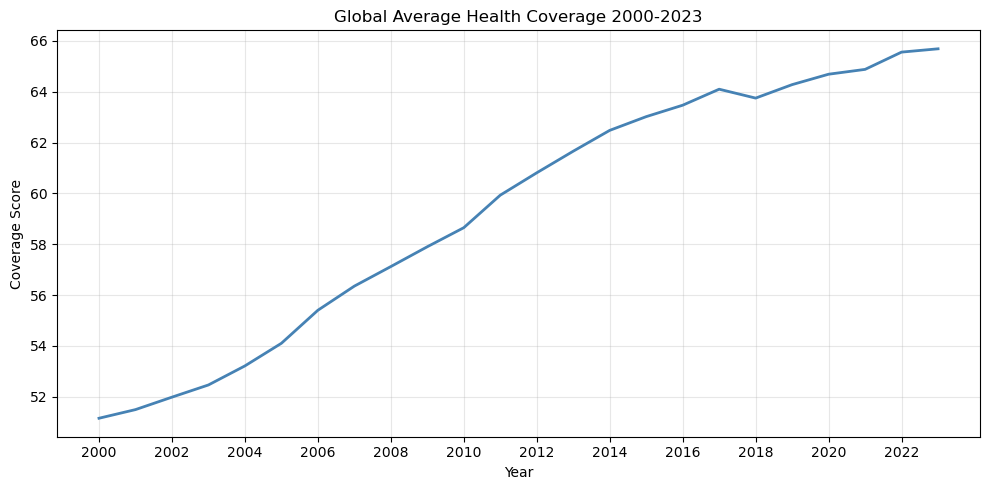

In [22]:
# Health Coverage trend
plt.figure(figsize=(10, 5))
plt.plot(hc_trend.index, hc_trend.values, color='steelblue', linewidth=2)
plt.title('Global Average Health Coverage 2000-2023')
plt.xlabel('Year')
plt.ylabel('Coverage Score')
plt.xticks(range(2000, 2024, 2), rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('EDA/hc_trend.png', dpi=150, bbox_inches='tight')
plt.show()

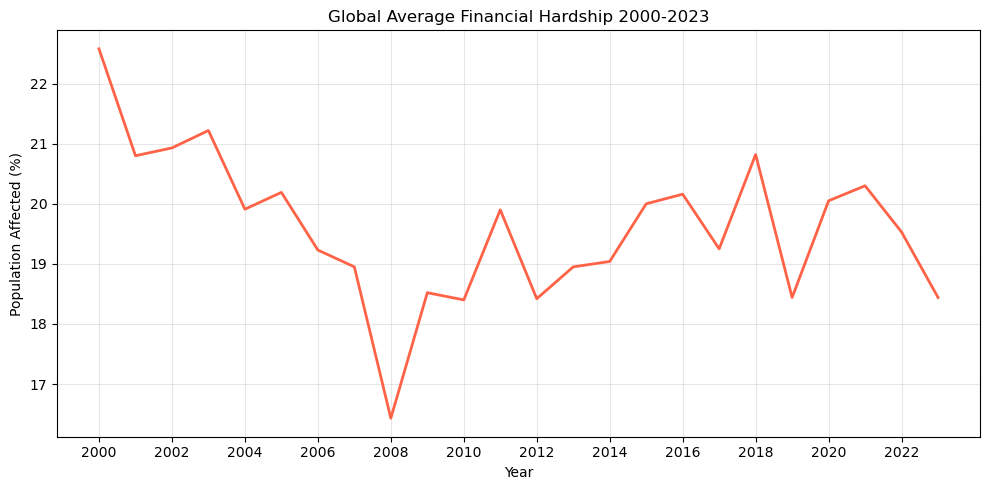

In [24]:
# Financial Hardship trend
plt.figure(figsize=(10, 5))
plt.plot(fh_trend.index, fh_trend.values, color='tomato', linewidth=2)
plt.title('Global Average Financial Hardship 2000-2023')
plt.xlabel('Year')
plt.ylabel('Population Affected (%)')
plt.xticks(range(2000, 2024, 2), rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('EDA/fh_trend.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# top 10 countries with highest average health coverage
hc_country = df_total.groupby('REF_AREA_LABEL')['hc_coverage'].mean().round(2).sort_values(ascending=False)
print("Top 10 - Health Coverage:")
print(hc_country.head(10))

Top 10 - Health Coverage:
REF_AREA_LABEL
Iceland           86.04
United States     84.46
Belgium           84.21
Switzerland       84.17
Germany           84.00
United Kingdom    83.96
Norway            83.29
Korea, Rep.       83.04
Portugal          82.92
Finland           82.79
Name: hc_coverage, dtype: float64


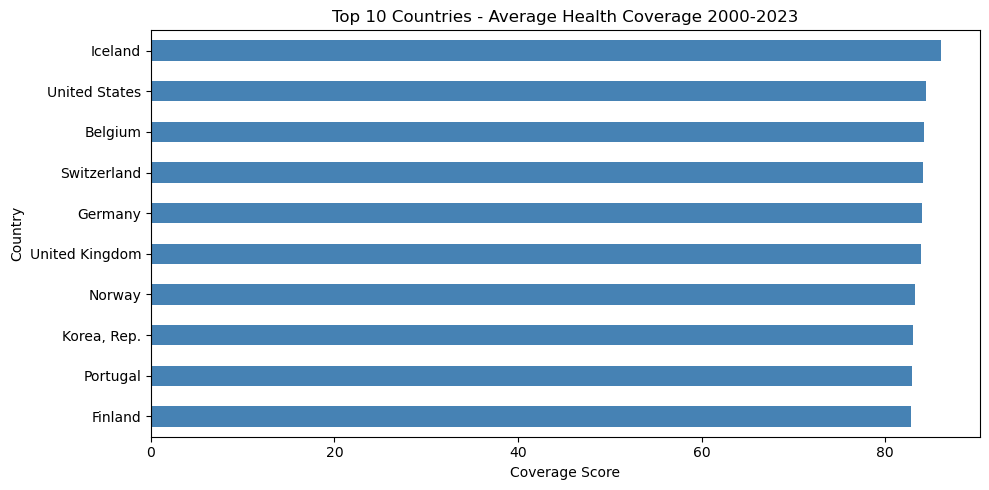

In [26]:
# Top 10 Health Coverage
plt.figure(figsize=(10, 5))
hc_country.head(10).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Countries - Average Health Coverage 2000-2023')
plt.xlabel('Coverage Score')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('EDA/top10_hc.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# bottom 10 countries with lowest average health coverage
print("Bottom 10 - Health Coverage:")
print(hc_country.tail(10))

Bottom 10 - Health Coverage:
REF_AREA_LABEL
Togo                           31.25
Benin                          30.08
South Sudan                    29.96
Guinea                         29.67
Niger                          29.29
Central African Republic       29.00
Madagascar                     26.25
Ethiopia                       23.00
Chad                           22.12
Federal Republic of Somalia    21.83
Name: hc_coverage, dtype: float64


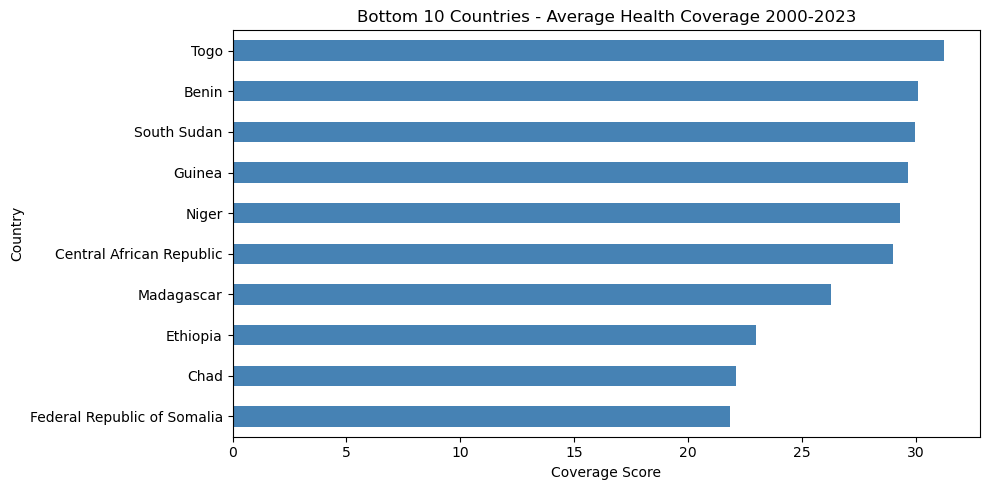

In [28]:
# Bottom 10 Health Coverage
plt.figure(figsize=(10, 5))
hc_country.tail(10).sort_values().plot(kind='barh', color='steelblue')
plt.title('Bottom 10 Countries - Average Health Coverage 2000-2023')
plt.xlabel('Coverage Score')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('EDA/bottom10_hc.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# top 10 countries with highest average financial hardship
fh_country = df_total.groupby('REF_AREA_LABEL')['financial_hardship'].mean().round(2).sort_values(ascending=False)
print("Top 10 - Financial Hardship:")
print(fh_country.head(10))

Top 10 - Financial Hardship:
REF_AREA_LABEL
Burundi             67.04
Sierra Leone        48.98
Niger               47.61
Congo, Dem. Rep.    46.66
Mali                45.28
Uganda              44.14
China               43.86
Cameroon            41.66
Madagascar          40.52
Guinea-Bissau       40.33
Name: financial_hardship, dtype: float64


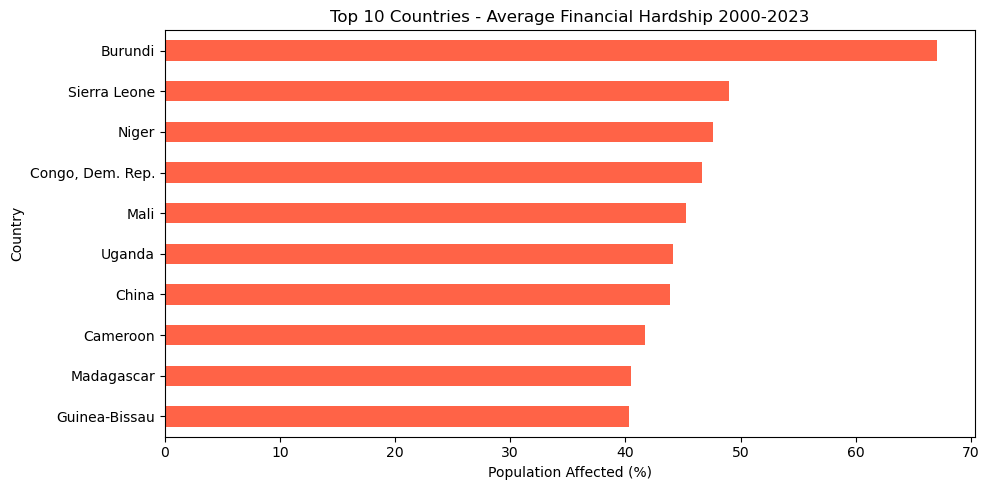

In [30]:
# Top 10 Financial Hardship
plt.figure(figsize=(10, 5))
fh_country.head(10).sort_values().plot(kind='barh', color='tomato')
plt.title('Top 10 Countries - Average Financial Hardship 2000-2023')
plt.xlabel('Population Affected (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('EDA/top10_fh.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# bottom 10 countries with lowest average financial hardship
print("Bottom 10 - Financial Hardship:")
print(fh_country.tail(10))

Bottom 10 - Financial Hardship:
REF_AREA_LABEL
Kiribati    1.42
Nauru       0.99
Tuvalu      0.46
Niue        0.00
Austria      NaN
Iceland      NaN
Lebanon      NaN
Norway       NaN
Oman         NaN
Sweden       NaN
Name: financial_hardship, dtype: float64


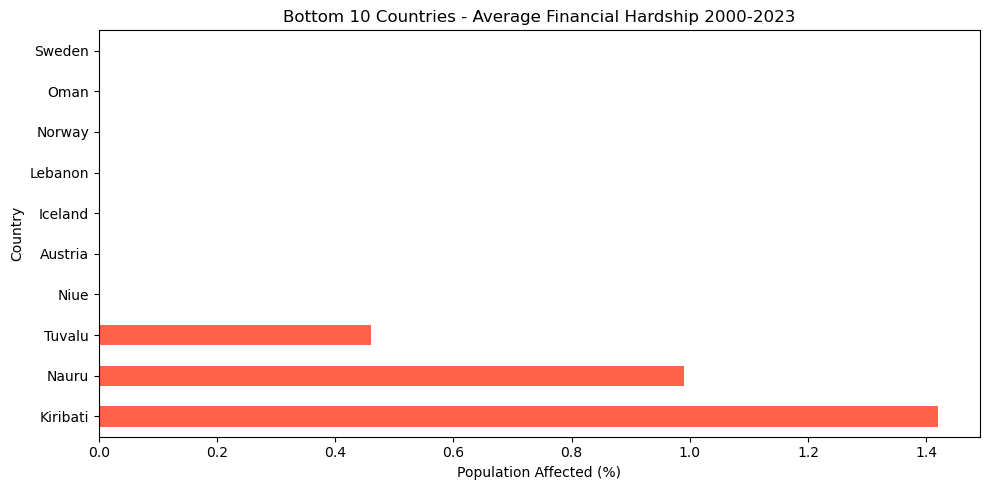

In [32]:
# Bottom 10 Financial Hardship
plt.figure(figsize=(10, 5))
fh_country.tail(10).sort_values(ascending=False).plot(kind='barh', color='tomato')
plt.title('Bottom 10 Countries - Average Financial Hardship 2000-2023')
plt.xlabel('Population Affected (%)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('EDA/bottom10_fh.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# filter to total rows and drop missing values
df_corr = df_total[['REF_AREA_LABEL', 'year', 'hc_coverage', 'financial_hardship']].dropna()

# correlation coefficient
correlation = df_corr['hc_coverage'].corr(df_corr['financial_hardship']).round(4)
print("Correlation between Health Coverage and Financial Hardship:", correlation)

Correlation between Health Coverage and Financial Hardship: -0.4827


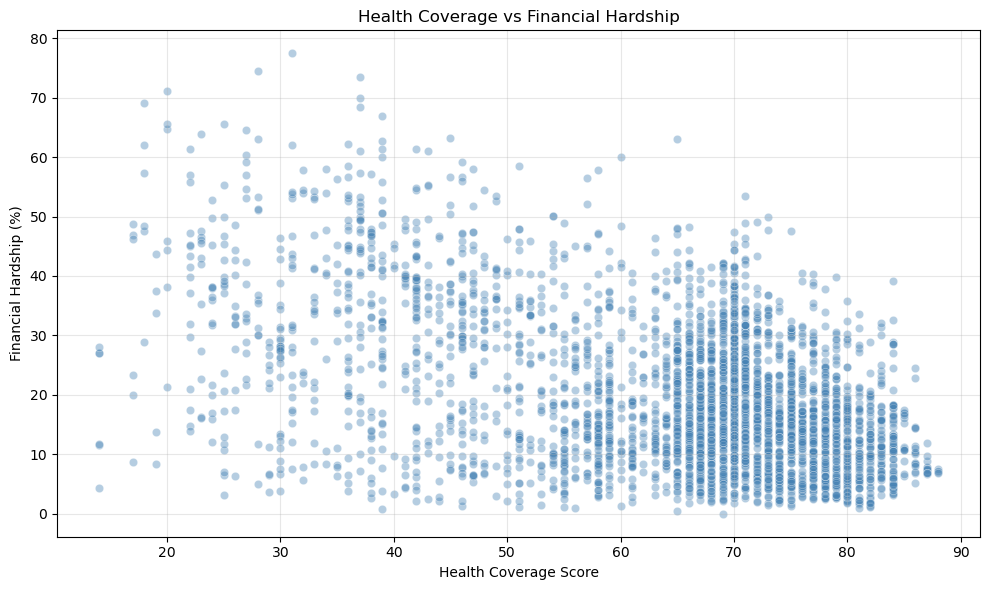

In [34]:
# scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_corr['hc_coverage'], df_corr['financial_hardship'], 
            alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.5)
plt.title('Health Coverage vs Financial Hardship')
plt.xlabel('Health Coverage Score')
plt.ylabel('Financial Hardship (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('EDA/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# missing data per year for health coverage
hc_missing = df_total.groupby('year')['hc_coverage'].apply(lambda x: x.isna().sum())
print("HC missing per year:")
print(hc_missing)

HC missing per year:
year
2000    0
2001    0
2002    0
2003    0
2004    0
2005    0
2006    0
2007    0
2008    0
2009    0
2010    0
2011    0
2012    0
2013    0
2014    0
2015    0
2016    0
2017    0
2018    0
2019    0
2020    0
2021    0
2022    0
2023    0
Name: hc_coverage, dtype: int64


In [36]:
# missing data per year for financial hardship
fh_missing = df_total.groupby('year')['financial_hardship'].apply(lambda x: x.isna().sum())
print("FH missing per year:")
print(fh_missing)

FH missing per year:
year
2000    631
2001    654
2002    589
2003    588
2004    595
2005    567
2006    591
2007    595
2008    577
2009    553
2010    536
2011    590
2012    550
2013    591
2014    576
2015    548
2016    551
2017    622
2018    565
2019    604
2020    671
2021    598
2022    622
2023    673
Name: financial_hardship, dtype: int64


In [37]:
# missing data per country for financial hardship (most problematic)
fh_missing_country = df_total.groupby('REF_AREA_LABEL')['financial_hardship'].apply(lambda x: x.isna().mean() * 100).round(2).sort_values(ascending=False)
print("Top 10 countries with most missing FH data:")
print(fh_missing_country.head(10))

Top 10 countries with most missing FH data:
REF_AREA_LABEL
Sweden                   100.00
Austria                  100.00
Iceland                  100.00
Oman                     100.00
Norway                   100.00
Lebanon                  100.00
Lesotho                   95.83
Micronesia, Fed. Sts.     95.83
Denmark                   95.83
Germany                   95.83
Name: financial_hardship, dtype: float64


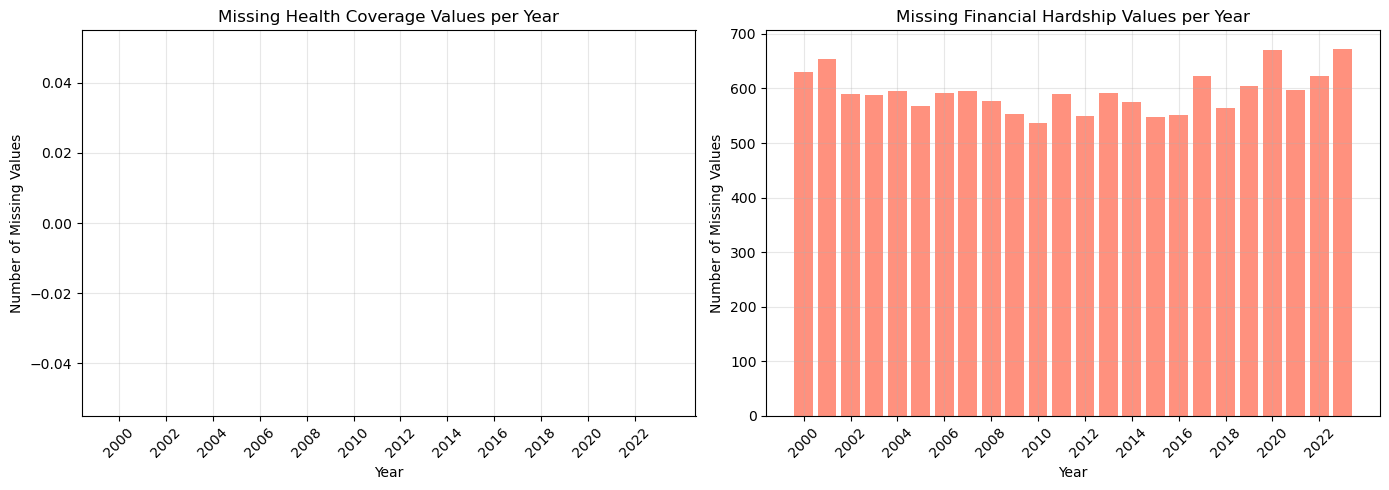

In [38]:
# missing data per year plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(hc_missing.index, hc_missing.values, color='steelblue', alpha=0.7)
ax1.set_title('Missing Health Coverage Values per Year')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Missing Values')
ax1.set_xticks(range(2000, 2024, 2))
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

ax2.bar(fh_missing.index, fh_missing.values, color='tomato', alpha=0.7)
ax2.set_title('Missing Financial Hardship Values per Year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Missing Values')
ax2.set_xticks(range(2000, 2024, 2))
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('EDA/missing_data.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# financial hardship by type - excluding All
fh_type = df[df['FINANCIAL_HARDSHIP_LABEL'] != 'All'].groupby('FINANCIAL_HARDSHIP_LABEL')['financial_hardship'].mean().round(2).sort_values(ascending=False)
print("Financial Hardship by Type:")
print(fh_type)

Financial Hardship by Type:
FINANCIAL_HARDSHIP_LABEL
Impoverishing           16.85
Further impoverished    15.45
Large OOP                3.67
Pushed into poverty      1.70
Name: financial_hardship, dtype: float64


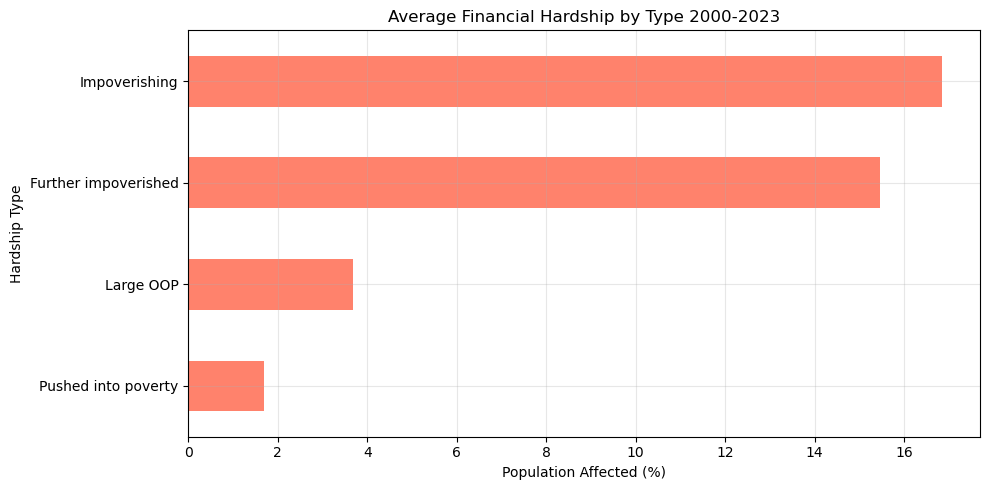

In [52]:
# plot it
plt.figure(figsize=(10, 5))
fh_type.sort_values().plot(kind='barh', color='tomato', alpha=0.8)
plt.title('Average Financial Hardship by Type 2000-2023')
plt.xlabel('Population Affected (%)')
plt.ylabel('Hardship Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('EDA/fh_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
# financial hardship by urbanization - excluding Total
fh_urban = df[df['URBANIZATION_LABEL'] != 'Total'].groupby('URBANIZATION_LABEL')['financial_hardship'].mean().round(2).sort_values(ascending=False)
print("Financial Hardship by Urbanization:")
print(fh_urban)

Financial Hardship by Urbanization:
URBANIZATION_LABEL
Rural area    28.33
Urban area    15.70
Name: financial_hardship, dtype: float64


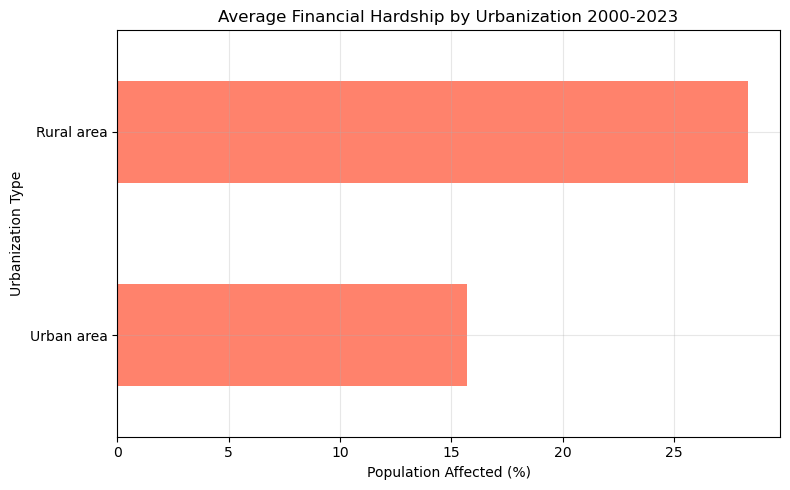

In [48]:
# plot urbanization
plt.figure(figsize=(8, 5))
fh_urban.sort_values().plot(kind='barh', color='tomato', alpha=0.8)
plt.title('Average Financial Hardship by Urbanization 2000-2023')
plt.xlabel('Population Affected (%)')
plt.ylabel('Urbanization Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('EDA/fh_by_urbanization.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# average financial hardship by wealth quintile
fh_quintile = df[df['IC_QUINTILE_LABEL'] != 'All'].groupby('IC_QUINTILE_LABEL')['financial_hardship'].mean().round(2).sort_values(ascending=False)
print("Financial Hardship by Wealth Quintile:")
print(fh_quintile)

Financial Hardship by Wealth Quintile:
IC_QUINTILE_LABEL
Wealth quintile 1 (poorest)    55.14
Wealth quintile 2              29.19
Wealth quintile 3              11.70
Wealth quintile 4               4.98
Wealth quintile 5 (richest)     2.63
Name: financial_hardship, dtype: float64


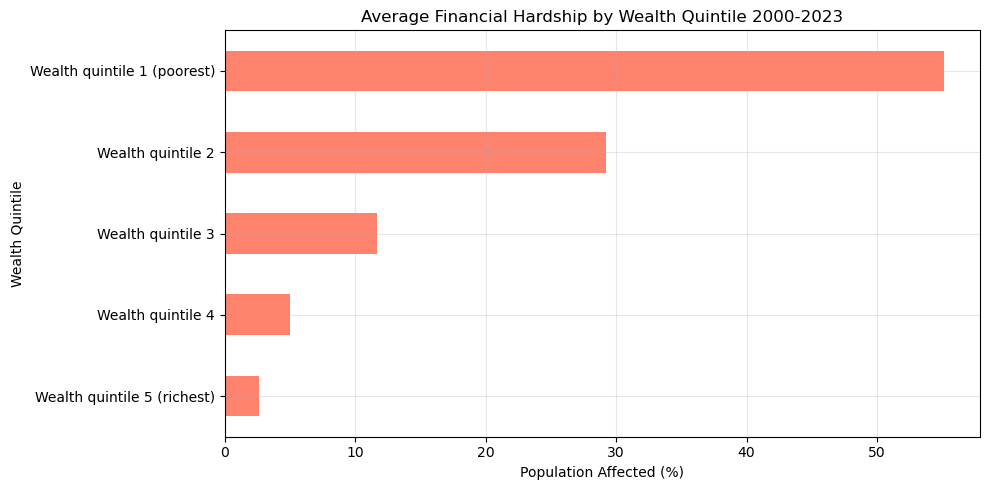

In [50]:
# plot quintile
plt.figure(figsize=(10, 5))
fh_quintile.sort_values().plot(kind='barh', color='tomato', alpha=0.8)
plt.title('Average Financial Hardship by Wealth Quintile 2000-2023')
plt.xlabel('Population Affected (%)')
plt.ylabel('Wealth Quintile')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('EDA/fh_by_quintile.png', dpi=150, bbox_inches='tight')
plt.show()